In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math
import sklearn.datasets


In [10]:
def sigmoid(x):
    """
    Compute the sigmoid of x
    Arguments:
    x -- A scalar or numpy array of any size.
    Return:
    s -- sigmoid(x)
    """
    s = 1/(1+np.exp(-x))
    return s
def softmax(x):
    """
    Compute the sigmoid of x
    Arguments:
    x -- A scalar or numpy array of any size.
    Return:
    s -- softmax(x)
    """
    t=np.exp(x)
    s = t/np.sum(t, axis=0)
    
    return s
def relu(x):
    """
    Compute the relu of x
    Arguments:
    x -- A scalar or numpy array of any size.
    Return:
    s -- relu(x)
    """
    s = np.maximum(0,x)
    
    return s

In [11]:
def update_parameters_with_gd(parameters, grads, learning_rate):  
    """  
    Update parameters using one step of gradient descent  
      
    Arguments:  
    parameters -- python dictionary containing your parameters to be updated:  
                    parameters['W' + str(l)] = Wl  
                    parameters['b' + str(l)] = bl  
    grads -- python dictionary containing your gradients to update each parameters:  
                    grads['dW' + str(l)] = dWl  
                    grads['db' + str(l)] = dbl  
    learning_rate -- the learning rate, scalar.  
      
    Returns:  
    parameters -- python dictionary containing your updated parameters   
    """  
  
    L = len(parameters) // 2 # number of layers in the neural networks  
  
    # Update rule for each parameter  
    for l in range(L):  
        ### START CODE HERE ### (approx. 2 lines)  
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - learning_rate*grads['dW' + str(l+1)]  
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate*grads['db' + str(l+1)]  
        ### END CODE HERE ###  
          
    return parameters  


In [12]:
def initialize_velocity(parameters):
    """
    Initializes the velocity as a python dictionary with:
                - keys: "dW1", "db1", ..., "dWL", "dbL" 
                - values: numpy arrays of zeros of the same shape as the corresponding gradients/parameters.
    Arguments:
    parameters -- python dictionary containing your parameters.
                    parameters['W' + str(l)] = Wl
                    parameters['b' + str(l)] = bl
    
    Returns:
    v -- python dictionary containing the current velocity.
                    v['dW' + str(l)] = velocity of dWl
                    v['db' + str(l)] = velocity of dbl
    """
    
    L = len(parameters) // 2 # number of layers in the neural networks
    v = {}
    
    # Initialize velocity
    for l in range(L):
        ### START CODE HERE ### (approx. 2 lines)
        v["dW" + str(l+1)] = np.zeros(parameters['W'+str(l+1)].shape)
        v["db" + str(l+1)] = np.zeros(parameters['b'+str(l+1)].shape)
        ### END CODE HERE ###
        
    return v

In [13]:
def update_parameters_with_momentum(parameters, grads, v, beta, learning_rate):  
    """  
    Update parameters using Momentum  
      
    Arguments:  
    parameters -- python dictionary containing your parameters:  
                    parameters['W' + str(l)] = Wl  
                    parameters['b' + str(l)] = bl  
    grads -- python dictionary containing your gradients for each parameters:  
                    grads['dW' + str(l)] = dWl  
                    grads['db' + str(l)] = dbl  
    v -- python dictionary containing the current velocity:  
                    v['dW' + str(l)] = ...  
                    v['db' + str(l)] = ...  
    beta -- the momentum hyperparameter, scalar  
    learning_rate -- the learning rate, scalar  
      
    Returns:  
    parameters -- python dictionary containing your updated parameters   
    v -- python dictionary containing your updated velocities  
    """  
  
    L = len(parameters) // 2 # number of layers in the neural networks, each layer has W and b  
      
    # Momentum update for each parameter  
    for l in range(L):  
          
        ### START CODE HERE ### (approx. 4 lines)  
        # compute velocities  
        v["dW" + str(l+1)] = beta * v['dW' + str(l+1)] + (1-beta)*(grads['dW' + str(l+1)])  
        v["db" + str(l+1)] = beta * v['db' + str(l+1)] + (1-beta)*(grads['db' + str(l+1)])  
        # update parameters  
        parameters["W" + str(l+1)] = parameters['W' + str(l+1)] - learning_rate * v['dW' + str(l+1)]  
        parameters["b" + str(l+1)] = parameters['b' + str(l+1)] - learning_rate * v['db' + str(l+1)]  
        ### END CODE HERE ###  
          
    return parameters, v  
  


In [14]:
def initialize_adam(parameters) :
    """
    Initializes v and s as two python dictionaries with:
                - keys: "dW1", "db1", ..., "dWL", "dbL" 
                - values: numpy arrays of zeros of the same shape as the corresponding gradients/parameters.
    
    Arguments:
    parameters -- python dictionary containing your parameters.
                    parameters["W" + str(l)] = Wl
                    parameters["b" + str(l)] = bl
    
    Returns: 
    v -- python dictionary that will contain the exponentially weighted average of the gradient.
                    v["dW" + str(l)] = ...
                    v["db" + str(l)] = ...
    s -- python dictionary that will contain the exponentially weighted average of the squared gradient.
                    s["dW" + str(l)] = ...
                    s["db" + str(l)] = ...

    """
    
    L = len(parameters) // 2 # number of layers in the neural networks
    v = {}
    s = {}
    
    # Initialize v, s. Input: "parameters". Outputs: "v, s".
    for l in range(L):
    ### START CODE HERE ### (approx. 4 lines)
        v["dW" + str(l+1)] = np.zeros(parameters['W' + str(l+1)].shape)
        v["db" + str(l+1)] = np.zeros(parameters['b' + str(l+1)].shape)
        s["dW" + str(l+1)] = np.zeros(parameters['W' + str(l+1)].shape)
        s["db" + str(l+1)] = np.zeros(parameters['b' + str(l+1)].shape)
    ### END CODE HERE ###
    
    return v, s

In [15]:
def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate = 0.01,
                                beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8):
    """
    Update parameters using Adam
    
    Arguments:
    parameters -- python dictionary containing your parameters:
                    parameters['W' + str(l)] = Wl
                    parameters['b' + str(l)] = bl
    grads -- python dictionary containing your gradients for each parameters:
                    grads['dW' + str(l)] = dWl
                    grads['db' + str(l)] = dbl
    v -- Adam variable, moving average of the first gradient, python dictionary
    s -- Adam variable, moving average of the squared gradient, python dictionary
    learning_rate -- the learning rate, scalar.
    beta1 -- Exponential decay hyperparameter for the first moment estimates 
    beta2 -- Exponential decay hyperparameter for the second moment estimates 
    epsilon -- hyperparameter preventing division by zero in Adam updates

    Returns:
    parameters -- python dictionary containing your updated parameters 
    v -- Adam variable, moving average of the first gradient, python dictionary
    s -- Adam variable, moving average of the squared gradient, python dictionary
    """
    
    L = len(parameters) // 2                 # number of layers in the neural networks
    v_corrected = {}                         # Initializing first moment estimate, python dictionary
    s_corrected = {}                         # Initializing second moment estimate, python dictionary
    
    # Perform Adam update on all parameters
    for l in range(L):
        # Moving average of the gradients. Inputs: "v, grads, beta1". Output: "v".
        ### START CODE HERE ### (approx. 2 lines)
        v["dW" + str(l+1)] = beta1 * v['dW' + str(l+1)] + (1-beta1) * grads['dW' + str(l+1)]
        v["db" + str(l+1)] = beta1 * v['db' + str(l+1)] + (1-beta1) * grads['db' + str(l+1)]
        ### END CODE HERE ###

        # Compute bias-corrected first moment estimate. Inputs: "v, beta1, t". Output: "v_corrected".
        ### START CODE HERE ### (approx. 2 lines)
        v_corrected["dW" + str(l+1)] = v['dW' + str(l+1)] / (1 - np.power(beta1, t))
        v_corrected["db" + str(l+1)] = v['db' + str(l+1)] / (1 - np.power(beta1, t))
        ### END CODE HERE ###

        # Moving average of the squared gradients. Inputs: "s, grads, beta2". Output: "s".
        ### START CODE HERE ### (approx. 2 lines)
        s["dW" + str(l+1)] = beta2 * s['dW' + str(l+1)] + (1-beta2) * np.power(grads['dW' + str(l+1)], 2)
        s["db" + str(l+1)] = beta2 * s['db' + str(l+1)] + (1-beta2) * np.power(grads['db' + str(l+1)], 2)
        ### END CODE HERE ###

        # Compute bias-corrected second raw moment estimate. Inputs: "s, beta2, t". Output: "s_corrected".
        ### START CODE HERE ### (approx. 2 lines)
        s_corrected["dW" + str(l+1)] = s['dW' + str(l+1)] / (1 - np.power(beta2, t))
        s_corrected["db" + str(l+1)] = s['db' + str(l+1)] / (1 - np.power(beta2, t))
        ### END CODE HERE ###

        # Update parameters. Inputs: "parameters, learning_rate, v_corrected, s_corrected, epsilon". Output: "parameters".
        ### START CODE HERE ### (approx. 2 lines)
        parameters["W" + str(l+1)] = parameters['W' + str(l+1)] - learning_rate * v_corrected['dW' + str(l+1)] / np.sqrt(s_corrected['dW' + str(l+1)] + epsilon)
        parameters["b" + str(l+1)] = parameters['b' + str(l+1)] - learning_rate * v_corrected['db' + str(l+1)] / np.sqrt(s_corrected['db' + str(l+1)] + epsilon)
        ### END CODE HERE ###

    return parameters, v, s


In [16]:
def random_mini_batches(X, Y, mini_batch_size = 64, seed = 0):
    """
    Creates a list of random minibatches from (X, Y)
    
    Arguments:
    X -- input data, of shape (input size, number of examples)
    Y -- true "label" vector (1 for blue dot / 0 for red dot), of shape (1, number of examples)
    mini_batch_size -- size of the mini-batches, integer
    
    Returns:
    mini_batches -- list of synchronous (mini_batch_X, mini_batch_Y)
    """
    
    np.random.seed(seed)            # To make your "random" minibatches deterministic
    m = X.shape[1]                  # number of training examples
    mini_batches = []
        
    # Step 1: Shuffle (X, Y)
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((Y.shape[0],m))

    # Step 2: Partition (shuffled_X, shuffled_Y). Minus the end case.
    num_complete_minibatches = math.floor(m/mini_batch_size) 
    # number of mini batches of size mini_batch_size in your partitionning
    for k in range(0, num_complete_minibatches):
        ### START CODE HERE: generate batches ### (approx. 2 lines)
        mini_batch_X = shuffled_X[:, k*mini_batch_size : (k+1)*mini_batch_size]
        mini_batch_Y = shuffled_Y[:, k*mini_batch_size : (k+1)*mini_batch_size]
        ### END CODE HERE ###
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)
        
           # Handling the end case (last mini-batch < mini_batch_size)
    if m % mini_batch_size != 0:
        ### START CODE HERE: the last batch ### (approx. 2 lines)
        mini_batch_X = shuffled_X[:, num_complete_minibatches*mini_batch_size:]
        mini_batch_Y = shuffled_Y[:, num_complete_minibatches*mini_batch_size:]
        ### END CODE HERE ###
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)
    
    return mini_batches


In [17]:
def initialize_parameters(layer_dims):
    """
    Arguments:
    layer_dims -- python array (list) containing the dimensions of each layer in our network
    
    Returns:
    parameters -- python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":
                    Wl -- weight matrix of shape (layer_dims[l], layer_dims[l-1])
                    bl -- bias vector of shape (layer_dims[l], 1)
                    
   
    """
    
    np.random.seed(3)
    parameters = {}
    L = len(layer_dims) # number of layers in the network

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1])*  np.sqrt(2 / layer_dims[l-1])
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
        
        assert(parameters['W' + str(l)].shape == layer_dims[l], layer_dims[l-1])
        assert(parameters['b' + str(l)].shape == layer_dims[l], 1)
        
    return parameters

<>:22: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:22: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:22: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<ipython-input-17-625e779587b5>:22: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(parameters['W' + str(l)].shape == layer_dims[l], layer_dims[l-1])
<ipython-input-17-625e779587b5>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(parameters['b' + str(l)].shape == layer_dims[l], 1)


In [18]:
def forward_propagation(X, parameters):
    """
    Implements the forward propagation (and computes the loss) presented in Figure 2.
    
    Arguments:
    X -- input dataset, of shape (input size, number of examples)
    parameters -- python dictionary containing your parameters "W1", "b1", "W2", "b2", "W3", "b3":
                    W1 -- weight matrix of shape (layer_dims[1], layer_dims[0])
                    b1 -- bias vector of shape ()
                    W2 -- weight matrix of shape ()
                    b2 -- bias vector of shape ()
                    W3 -- weight matrix of shape ()
                    b3 -- bias vector of shape ()
    
    Returns:
    loss -- the loss function (vanilla logistic loss)
    """
    
    # retrieve parameters
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]
    
    # LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID
    z1 = np.dot(W1, X) + b1
    a1 = relu(z1)
    z2 = np.dot(W2, a1) + b2
    a2 = relu(z2)
    z3 = np.dot(W3, a2) + b3
    a3 = softmax(z3)
    
    cache = (z1, a1, W1, b1, z2, a2, W2, b2, z3, a3, W3, b3)
    
    return a3, cache

In [19]:
def compute_cost(a3, Y):
    
    """
    Implement the cost function
    
    Arguments:
    a3 -- post-activation, output of forward propagation
    Y -- "true" labels vector, same shape as a3
    
    Returns:
    cost - value of the cost function
    """
    m = Y.shape[1]
    k = Y.shape[0]
    if k==1: # sigmoid for 2 classes
        logprobs = np.multiply(-np.log(a3),Y) + np.multiply(-np.log(1 - a3), 1 - Y)
        cost = 1./m * np.sum(logprobs)
    
    else:  #softmax for multiple classes, each column in Y is one-hot-code
        logprobs = np.multiply(np.log(a3),Y)
        cost = -1/m*np.sum(logprobs)
        cost = np.squeeze(cost)
    return cost

In [20]:
def backward_propagation(X, Y, cache):
    """
    Implement the backward propagation presented in figure 2.
    
    Arguments:
    X -- input dataset, of shape (input size, number of examples)
    Y -- true "label" vector (containing 0 if cat, 1 if non-cat)
    cache -- cache output from forward_propagation()
    
    Returns:
    gradients -- A dictionary with the gradients with respect to each parameter, activation and pre-activation variables
    """
    m = X.shape[1]
    (z1, a1, W1, b1, z2, a2, W2, b2, z3, a3, W3, b3) = cache
    
    dz3 = 1./m * (a3 - Y)
    dW3 = np.dot(dz3, a2.T)
    db3 = np.sum(dz3, axis=1, keepdims = True)
    
    da2 = np.dot(W3.T, dz3)
    dz2 = np.multiply(da2, np.int64(a2 > 0))
    dW2 = np.dot(dz2, a1.T)
    db2 = np.sum(dz2, axis=1, keepdims = True)
    
    da1 = np.dot(W2.T, dz2)
    dz1 = np.multiply(da1, np.int64(a1 > 0))
    dW1 = np.dot(dz1, X.T)
    db1 = np.sum(dz1, axis=1, keepdims = True)
    
    gradients = {"dz3": dz3, "dW3": dW3, "db3": db3,
                 "da2": da2, "dz2": dz2, "dW2": dW2, "db2": db2,
                 "da1": da1, "dz1": dz1, "dW1": dW1, "db1": db1}
    
    return gradients

In [21]:
def model(X, Y, layers_dims, optimizer, learning_rate = 0.0007, mini_batch_size = 64, beta = 0.9,
          beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8, num_epochs = 10000, print_cost = True):
    """
    3-layer neural network model which can be run in different optimizer modes.
    
    Arguments:
    X -- input data, of shape (2, number of examples)
    Y -- true "label" vector (1 for blue dot / 0 for red dot), of shape (1, number of examples)
    layers_dims -- python list, containing the size of each layer
    learning_rate -- the learning rate, scalar.
    mini_batch_size -- the size of a mini batch
    beta -- Momentum hyperparameter
    beta1 -- Exponential decay hyperparameter for the past gradients estimates 
    beta2 -- Exponential decay hyperparameter for the past squared gradients estimates 
    epsilon -- hyperparameter preventing division by zero in Adam updates
    num_epochs -- number of epochs
    print_cost -- True to print the cost every 1000 epochs

    Returns:
    parameters -- python dictionary containing your updated parameters 
    """

    L = len(layers_dims)             # number of layers in the neural networks
    costs = []                       # to keep track of the cost
    t = 0                            # initializing the counter required for Adam update
    seed = 10                        # For grading purposes, so that your "random" minibatches are the same as ours
    
    # Initialize parameters
    parameters = initialize_parameters(layers_dims)
     # Initialize the optimizer
    if optimizer == "gd":
        pass # no initialization required for gradient descent
    elif optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)
    
    # Optimization loop
    for i in range(num_epochs):
        
        # Define the random minibatches. We increment the seed to reshuffle differently the dataset after each epoch
        seed = seed + 1
        minibatches = random_mini_batches(X, Y, mini_batch_size, seed)

        for minibatch in minibatches:

            # Select a minibatch
            (minibatch_X, minibatch_Y) = minibatch

            # Forward propagation
            a3, caches = forward_propagation(minibatch_X, parameters)

            # Compute cost
            cost = compute_cost(a3, minibatch_Y)
         # Backward propagation
            grads = backward_propagation(minibatch_X, minibatch_Y, caches)

            # Update parameters
            if optimizer == "gd":
                parameters = update_parameters_with_gd(parameters, grads, learning_rate)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, learning_rate)
            elif optimizer == "adam":
                t = t + 1 # Adam counter
                parameters, v, s = update_parameters_with_adam(parameters, grads, v, s,
                                                               t, learning_rate, beta1, beta2,  epsilon)
        
        # Print the cost every 1000 epoch
        if print_cost and i % 100 == 0:
            #print(t)
            print ("Cost after epoch %i: %f" %(i, cost))
#       if print_cost and i % 10 == 0:
        if print_cost and i % 10 == 0:    
            costs.append(cost)
                
    # plot the cost
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('epochs (per 10)')
    plt.title("Learning rate = " + str(learning_rate))
    plt.show()

    return parameters, costs

In [22]:
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)].T
    return Y

In [40]:
def load_dataset():
    np.random.seed(3)
    train_X, train_Y = sklearn.datasets.make_moons(n_samples=300, noise=.2) #300 #0.2 
    # Visualize the data
    plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y.ravel(), s=40, cmap=plt.cm.Spectral);
    train_X = train_X.T
    train_Y = train_Y.reshape((1, train_Y.shape[0]))
    
    return train_X, train_Y

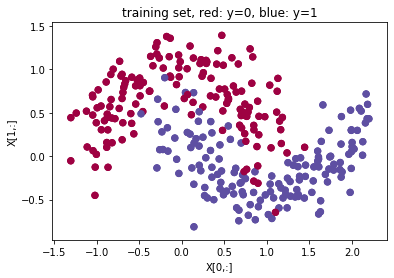

In [41]:
train_X, train_Y = load_dataset()

plt.scatter(train_X[0, :], train_X[1, :],c=train_Y[0,:], s=40, cmap=plt.cm.Spectral)
plt.xlabel("X[0,:]")
plt.ylabel("X[1,:]")
plt.title("training set, red: y=0, blue: y=1")
plt.show()


In [23]:
def predict(X, parameters):
    """
    This function is used to predict the results of a  n-layer neural network.
    
    Arguments:
    X -- data set of examples you would like to label
    parameters -- parameters of the trained model
    
    Returns:
    y_esti -- predictions (labels:0,1,2,3,4,,5) for the given dataset X
    """
    
    m = X.shape[1]
    y_esti = np.zeros((1,m), dtype = np.int)
    # Forward propagation
    a3, caches = forward_propagation(X, parameters)
    
    
    for i in range(0, a3.shape[1]):
        y_esti[0,i]=np.argmax(a3[:,i])
    
    return y_esti

In [24]:
def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole grid
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap=plt.cm.Spectral)
    plt.show()
    
def predict_dec(parameters, X):
    """
    Used for plotting decision boundary.
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    X -- input data of size (m, K)
    
    Returns
    predictions -- vector of predictions of our model (red: 0 / blue: 1)
    """
    
    # Predict using forward propagation and a classification threshold of 0.5
    a3, cache = forward_propagation(X, parameters)
    predictions = (a3 > 0.5)
    return predictions


Cost after epoch 0: 0.706019
Cost after epoch 100: 0.221365
Cost after epoch 200: 0.199276
Cost after epoch 300: 0.100450
Cost after epoch 400: 0.054298
Cost after epoch 500: 0.229595
Cost after epoch 600: 0.127700
Cost after epoch 700: 0.129801
Cost after epoch 800: 0.102676
Cost after epoch 900: 0.152990


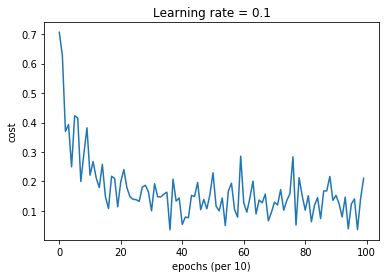

accuracy of train set is 0.94


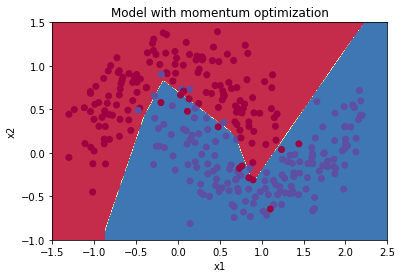

In [23]:
layers_dims = [train_X.shape[0], 5, 2, 2]
train_Y_hot = convert_to_one_hot(train_Y, 2)
#     model(X, Y, layers_dims, optimizer, learning_rate = 0.0007, mini_batch_size = 64, beta = 0.9,
#           beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8, num_epochs = 10000, print_cost = True)
# 

parameters, costs=model(train_X, train_Y_hot, layers_dims, optimizer="momentum", learning_rate = 0.1, mini_batch_size = 64, beta = 0.9,
          beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8, num_epochs = 1000, print_cost = True)
# Predict
predictions = predict(train_X, parameters)
accuracy = np.mean(predictions == train_Y)

print("accuracy of train set is "+ str(accuracy))
# Predict
#predictions = predict(train_X, train_Y, parameters)
 # Plot decision boundary
plt.title("Model with momentum optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict(x.T, parameters), train_X, train_Y)


In [29]:
import h5py
def load_dataset_signs():
    train_dataset = h5py.File('C:\\machine_learning\\NN_m_class\\train_signs.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File('C:\\machine_learning\\NN_m_class\\test_signs.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

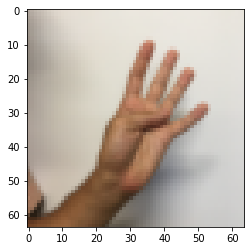

y = 4


In [31]:
# Loading the dataset
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset_signs()
# Example of a picture
index = 5
plt.imshow(X_train_orig[index])
plt.show()
print ("y = " + str(np.squeeze(Y_train_orig[:, index])))

In [33]:
# Flatten the training and test images
X_train_flatten = X_train_orig.reshape(X_train_orig.shape[0], -1).T
X_test_flatten = X_test_orig.reshape(X_test_orig.shape[0], -1).T
# Normalize image vectors
X_train = X_train_flatten/255.
X_test = X_test_flatten/255.
# Convert training and test labels to one hot matrices
Y_train = convert_to_one_hot(Y_train_orig, 6)
Y_test = convert_to_one_hot(Y_test_orig, 6)

print ("number of training examples = " + str(X_train.shape[1]))
print ("number of test examples = " + str(X_test.shape[1]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 1080
number of test examples = 120
X_train shape: (12288, 1080)
Y_train shape: (6, 1080)
X_test shape: (12288, 120)
Y_test shape: (6, 120)


Cost after epoch 0: 1.769904
Cost after epoch 100: 1.159022
Cost after epoch 200: 0.523895
Cost after epoch 300: 0.132281
Cost after epoch 400: 0.159506
Cost after epoch 500: 0.128522
Cost after epoch 600: 0.129941
Cost after epoch 700: 0.049313
Cost after epoch 800: 0.114292
Cost after epoch 900: 0.020950
Cost after epoch 1000: 0.018487
Cost after epoch 1100: 0.011649
Cost after epoch 1200: 0.015100
Cost after epoch 1300: 0.019204
Cost after epoch 1400: 0.008309


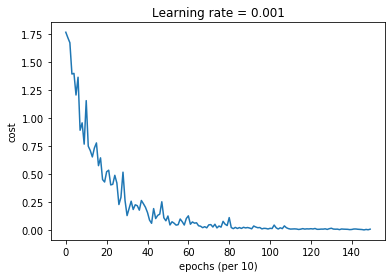

accuracy of train set is 1.0
accuracy of test set is 0.9083333333333333


In [34]:
# train 3-layer model
#layers_dims = [X_train.shape[0], 25, 12, 6]
layers_dims = [X_train.shape[0], 30, 20, 6]
#parameters, costs = model(X_train, Y_train, layers_dims, optimizer="adam", learning_rate = 0.0001, mini_batch_size = 32, num_epochs = 1500)
parameters, costs=model(X_train, Y_train, layers_dims, optimizer="gd", learning_rate = 0.001, mini_batch_size = 32, beta = 0.9,
          beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8, num_epochs = 1500, print_cost = True)
# Predict
predictions = predict(X_train, parameters)
accuracy = np.mean(predictions == Y_train_orig)

print("accuracy of train set is "+ str(accuracy))

predictions = predict(X_test, parameters)
accuracy = np.mean(predictions == Y_test_orig)

print("accuracy of test set is "+ str(accuracy))


# applied to MNIST dataset

In [88]:
#image_size = 28 # width and length
#n_of_different_labels = 10 #  i.e. 0, 1, 2, 3, ..., 9
#image_pixels = image_size * image_size
train_data = np.loadtxt("C:/machine_learning/NN_nn_overview/mnist_train.csv", 
                        delimiter=",")
test_data = np.loadtxt("C:/machine_learning/NN_nn_overview/mnist_test.csv", 
                       delimiter=",") 


In [89]:
fac = 0.99/255 # convert [0,255] to [0,1]
train_imgs = np.asfarray(train_data[:, 1:])*fac+0.01
test_imgs = np.asfarray(test_data[:, 1:])*fac+0.01
# first column for labels

train_labels = np.asfarray(train_data[:,:1])
test_labels = np.asfarray(test_data[:, :1])


In [90]:
print ('The shape of train_imgs is: ' + str(train_imgs.shape))
print ('The shape of train_labels is: ' + str(train_labels.shape))
print ('The shape of test_imgs is: ' + str(test_imgs.shape))
print ('The shape of test_labels is: ' + str(test_labels.shape))


The shape of train_imgs is: (60000, 784)
The shape of train_labels is: (60000, 1)
The shape of test_imgs is: (10000, 784)
The shape of test_labels is: (10000, 1)


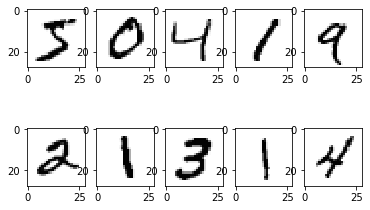

In [91]:
# display the first 10 examples
for i in range(10):
    img = train_imgs[i].reshape((28,28))
    plt.subplot(2,5,1+i)
    plt.imshow(img, cmap="Greys")
plt.show()


In [92]:
train_imgs_T=np.transpose(train_imgs)  # shape to (784, 60000)
test_imgs_T=np.transpose(test_imgs)    # shape to (784, 10000)
train_labels_T=np.transpose(train_labels)  # shape to (1, 60000)
test_labels_T=np.transpose(test_labels)  # shape to (1, 10000)

In [93]:
train_Y_hot = convert_to_one_hot(train_labels_T.astype(int), 10)  # shape (10, 60000)
test_Y_hot = convert_to_one_hot(test_labels_T.astype(int), 10)  # shape (10, 10000)

Cost after epoch 0: 1.576470


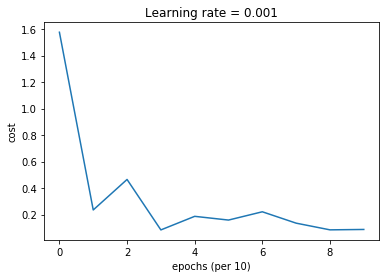

accuracy of train set is 0.95945
accuracy of test set is 0.9558


In [95]:
# train 3-layer model
#layers_dims = [X_train.shape[0], 25, 12, 6]
layers_dims = [train_imgs_T.shape[0], 30, 20, 10]
#parameters, costs = model(X_train, Y_train, layers_dims, optimizer="adam", learning_rate = 0.0001, mini_batch_size = 32, num_epochs = 1500)
parameters, costs=model(train_imgs_T, train_Y_hot, layers_dims, optimizer="gd", learning_rate = 0.001, mini_batch_size = 32, beta = 0.9,
          beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8, num_epochs = 100, print_cost = True)
# Predict
predictions = predict(train_imgs_T, parameters)
accuracy = np.mean(predictions == train_labels_T)

print("accuracy of train set is "+ str(accuracy))

predictions = predict(test_imgs_T, parameters)
accuracy = np.mean(predictions == test_labels_T)
print("accuracy of test set is "+ str(accuracy))

In [84]:
accuracy = np.mean(predictions == train_labels_T)

In [85]:
accuracy

0.9884666666666667

In [86]:
predictions

array([[5, 0, 4, ..., 5, 6, 8]])